In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Credal-Set-Informed Decoding

| Parameter | Wert |
|-----------|------|
| Prompts | 100 aus WritingPrompts |
| Samples/Prompt | 10 |
| Modelle | Gemma-2-2B, Mistral-7B-Instruct, LLaMA-3.1-8B-Instruct |
| Human-Daten | Aus uncertainHuman Repository / WritingPrompts |
| Metriken | SBERT cosine, Jaccard bigrams, Jaccard POS trigrams |

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import json
import os
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from sentence_transformers import SentenceTransformer
import spacy
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
from itertools import combinations
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Konfiguration

Passe `N_PROMPTS` an für schnelle Tests (10) oder volles Experiment (100+).

In [3]:
# Konfiguration
N_PROMPTS = 10
N_SAMPLES = 10
MAX_NEW_TOKENS = 150

# Modelle
MODEL_IDS = {'qwen-3-4b': 'Qwen/Qwen3-4B'}

# Decoding Baselines
STRATEGIES = {
    'temp_0.7':  dict(temperature=0.7, top_p=0.95, top_k=0),
    'temp_1.2':  dict(temperature=1.2, top_p=0.95, top_k=0),
    'top_p_0.9': dict(temperature=1.0, top_p=0.90, top_k=0),
    'top_k_40':  dict(temperature=1.0, top_p=1.0,  top_k=40),
    'typical':   dict(temperature=0.95, top_p=0.92, top_k=0),
}

# Output-Ordner
OUT_DIR = Path('results')
OUT_DIR.mkdir(exist_ok=True)

print(f'Experiment: {N_PROMPTS} Prompts × {N_SAMPLES} Samples × {len(MODEL_IDS)} Modelle × {len(STRATEGIES)+1} Strategien')
print(f'Geschätzte Generierungen: {N_PROMPTS * N_SAMPLES * len(MODEL_IDS) * (len(STRATEGIES)+1)}')

Experiment: 10 Prompts × 10 Samples × 1 Modelle × 6 Strategien
Geschätzte Generierungen: 600


## 2. Human-Daten laden

In [4]:
from pathlib import Path

def load_human_data(n_prompts=100, n_stories=10):

    local_path = Path('/content/drive/MyDrive/Masterarbeit/Prototypes/human_drift/clean_generations/human_storytelling_clean.json')

    with open(local_path) as f:
        data = json.load(f)

    prompts, human_stories = [], {}
    for i, (prompt, stories) in enumerate(data.items()):
        if i >= n_prompts:
            break
        prompts.append(prompt.strip())
        human_stories[i] = stories[:n_stories]

    print(f'Daten geladen: {len(prompts)} Prompts mit je {n_stories} Stories')
    return prompts, human_stories

print('=== Human-Daten laden ===')
PROMPTS, HUMAN_STORIES = load_human_data(N_PROMPTS, N_SAMPLES)

print(f'\nBeispiel-Prompt: "{PROMPTS[0][:100]}..."')
print(f'Beispiel-Story:  "{HUMAN_STORIES[0][0][:100]}..."')

=== Human-Daten laden ===
Daten geladen: 10 Prompts mit je 10 Stories

Beispiel-Prompt: "[ WP ] Leonardo DiCaprio in a fit of rage begins to torpedo his own career by deliberately acting po..."
Beispiel-Story:  "The wet marble floor pressed on his cheek like a thousand hands slapping his face frozen in time. Sm..."


## 3. Diversitätsmetriken

In [5]:
# SBERT + spaCy laden
sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=DEVICE)
nlp = spacy.load('en_core_web_sm')
print('SBERT und spaCy geladen')


def compute_diversity(texts: List[str]) -> np.ndarray:
    """Berechne [d_sem, d_lex, d_syn]

    - Semantic: Cosine distance auf paraphrase-multilingual-MiniLM-L12-v2
    - Lexical: Jaccard distance auf Word-Bigram-Sets
    - Syntactic: Jaccard distance auf POS-Trigram-Sets
    """
    if len(texts) < 2:
        return np.array([0.0, 0.0, 0.0])

    n = len(texts)
    pairs = list(combinations(range(n), 2))

    # Semantic
    embs = sbert.encode(texts, normalize_embeddings=True, show_progress_bar=False)
    d_sem = np.mean([1.0 - np.dot(embs[i], embs[j]) for i, j in pairs])

    # Lexical
    def bigrams(text):
        w = text.lower().split()

        return set(zip(w[:-1], w[1:])) if len(w) >= 2 else set()

    bgs = [bigrams(t) for t in texts]
    d_lex = np.mean([
        1.0 - len(bgs[i] & bgs[j]) / max(len(bgs[i] | bgs[j]), 1)
        for i, j in pairs
    ])

    # Syntactic
    def pos_tri(text):
        doc = nlp(text[:800])  # truncate
        tags = [t.pos_ for t in doc]

        return set(zip(tags[:-2], tags[1:-1], tags[2:])) if len(tags) >= 3 else set()

    pts = [pos_tri(t) for t in texts]
    d_syn = np.mean([
        1.0 - len(pts[i] & pts[j]) / max(len(pts[i] | pts[j]), 1)
        for i, j in pairs
    ])

    return np.array([d_sem, d_lex, d_syn])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SBERT und spaCy geladen


## 4. Human-Diversitätsvektoren berechnen

In [6]:
print('Berechne Human-Diversitätsvektoren:')
human_vectors = []
t0 = time.time()

for pi in range(len(PROMPTS)):
    stories = HUMAN_STORIES[pi]
    v = compute_diversity(stories[:N_SAMPLES])
    human_vectors.append(v)

    if (pi + 1) % 10 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (pi + 1) * (len(PROMPTS) - pi - 1)

        print(f'  {pi+1}/{len(PROMPTS)} ({elapsed:.0f}s, ETA {eta:.0f}s)', end='\r')

human_vectors = np.array(human_vectors)

print(f'\nHuman-Vektoren: {human_vectors.shape} in {time.time()-t0:.0f}s')
print(f'  Semantic: {human_vectors[:,0].mean():.3f} ± {human_vectors[:,0].std():.3f}')
print(f'  Lexical:  {human_vectors[:,1].mean():.3f} ± {human_vectors[:,1].std():.3f}')
print(f'  Syntactic:{human_vectors[:,2].mean():.3f} ± {human_vectors[:,2].std():.3f}')

H_CENTROID = human_vectors.mean(0)
H_STDS = human_vectors.std(0)
print(f'\nHuman Centroid: {H_CENTROID.round(3)}')

Berechne Human-Diversitätsvektoren:
  10/10 (8s, ETA 0s)
Human-Vektoren: (10, 3) in 8s
  Semantic: 0.672 ± 0.033
  Lexical:  0.984 ± 0.003
  Syntactic:0.830 ± 0.014

Human Centroid: [0.672 0.984 0.83 ]


## 5. Modell-Utilities

In [7]:
def load_model(model_id: str):
    """Lade Modell mit 4-bit Quantisierung (spart VRAM)"""
    print(f'Lade {model_id}...')

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=quant_config,
        device_map='auto',
    )
    model.eval()

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.eos_token_id

    n_params = sum(p.numel() for p in model.parameters()) / 1e9
    print(f'  Geladen: {n_params:.1f}B params (4-bit)')
    return model, tokenizer


def format_prompt(prompt: str, tokenizer, model_id: str) -> str:
    """Formatiere Prompt mit Chat-Template falls verfügbar"""
    system = "You are a creative fiction writer. Write a story continuation based on the given writing prompt. Output only the story text."

    if hasattr(tokenizer, 'apply_chat_template') and tokenizer.chat_template:
        messages = [
            {'role': 'system', 'content': system},
            {'role': 'user', 'content': prompt},
        ]
        try:
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            pass

    # Fallback: Prompt direkt verwenden
    return f"{system}\n\n{prompt}\n\n"


def generate_samples(
    prompt: str,
    model, tokenizer,
    model_id: str,
    n: int = 10,
    temperature: float = 0.7,
    top_p: float = 0.95,
    top_k: int = 0,
) -> List[str]:
    """Generiere n Samples für einen Prompt"""
    formatted = format_prompt(prompt, tokenizer, model_id)
    inputs = tokenizer(formatted, return_tensors='pt').to(model.device)
    prompt_len = inputs['input_ids'].shape[1]

    gen_kwargs = dict(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=max(temperature, 0.01),
        num_return_sequences=n,
        pad_token_id=tokenizer.eos_token_id,
    )

    if top_k > 0:
        gen_kwargs['top_k'] = top_k

    else:
        gen_kwargs['top_p'] = top_p

    with torch.no_grad():
        outputs = model.generate(**gen_kwargs)

    texts = []
    for seq in outputs:
        t = tokenizer.decode(seq[prompt_len:], skip_special_tokens=True).strip()
        if t:
            texts.append(t)

    return texts

## 6. Metriken

In [8]:
DIM_NAMES = ['Semantic', 'Lexical', 'Syntactic']

def overlap_coeff(a, b):
    """Overlap mit adaptivem Threshold: Theta = sqrt((Var(A) + Var(B)) / 2)"""
    d1 = cdist(a, b).min(1); d2 = cdist(b, a).min(1)
    theta = np.sqrt(np.mean([np.var(a,0).mean(), np.var(b,0).mean()]))

    return 0.5 * (np.mean(d1 < theta) + np.mean(d2 < theta))

def mean_nn_distance(a, b):
    """Mittlere Nearest-Neighbor-Distanz"""
    d1 = cdist(a, b).min(1).mean()  # mean min-dist A -> B
    d2 = cdist(b, a).min(1).mean()  # mean min-dist B -> A

    return 0.5 * (d1 + d2)

def hausdorff(a, b):
    d = cdist(a, b)
    return max(d.min(1).max(), d.min(0).max())

def w_per_dim(a, b):
    return np.array([wasserstein_distance(a[:,i], b[:,i]) for i in range(3)])

def w_total(a, b):
    """Gesamte Wasserstein-Distanz (Summe über Dimensionen)"""
    return float(w_per_dim(a, b).sum())

def eval_all(vecs):
    return dict(
        overlap=overlap_coeff(vecs, human_vectors),
        mean_nn=mean_nn_distance(vecs, human_vectors),
        hausdorff=hausdorff(vecs, human_vectors),
        centroid_d=np.linalg.norm(vecs.mean(0) - H_CENTROID),
        wasserstein=w_per_dim(vecs, human_vectors),
        w_total=w_total(vecs, human_vectors),
        mean=vecs.mean(0),
        std=vecs.std(0),
    )

## 7. Credal-Informed Decoding

In [9]:
@dataclass
class CredalConfig:
    tau_init: float = 0.7
    top_p_init: float = 0.95
    alpha: float = 0.15
    beta: float = 0.8
    alpha_p: float = 0.03
    tau_min: float = 0.3
    tau_max: float = 2.0
    p_min: float = 0.80
    p_max: float = 0.99
    warmup: int = 3
    update_every: int = 1
    dim_weights: Optional[np.ndarray] = None


def credal_decode(
    prompts: List[str],
    model, tokenizer, model_id: str,
    cfg: CredalConfig = CredalConfig(),
) -> Tuple[np.ndarray, List[Dict]]:
    """Credal-Set-Informed Adaptive Decoding"""
    # Dimensionen gewichten (default: gleich)
    w = cfg.dim_weights if cfg.dim_weights is not None else np.ones(3) / 3
    tau, top_p = cfg.tau_init, cfg.top_p_init
    vecs, history = [], []

    # Iteriere über Prompts und generiere Samples
    for pi, prompt in enumerate(prompts):
        set_seed(pi * 100)
        # Generate Samples
        texts = generate_samples(prompt, model, tokenizer, model_id,
                                 n=N_SAMPLES, temperature=tau, top_p=top_p)
        v = compute_diversity(texts)
        vecs.append(v)

        # Abstand zum Human-Centroid
        cd = np.linalg.norm(np.mean(vecs, 0) - H_CENTROID)
        history.append(dict(step=pi, tau=tau, top_p=top_p, vector=v, centroid_d=cd))

        # Fortschrittsanzeige
        if (pi+1) % 5 == 0:
            print(f'  [{pi+1}/{len(prompts)}] τ={tau:.2f} top_p={top_p:.3f} cd={cd:.3f}', end='\r')

        # Adaptives Update nach Warmup-Phase und alle cfg.update_every Schritte
        if len(vecs) >= cfg.warmup and (pi+1) % cfg.update_every == 0:
            delta = (H_CENTROID - np.mean(vecs, 0)) / (H_STDS + 1e-8)
            sig = np.sum(w * np.sign(delta) * np.abs(delta) ** cfg.beta)
            tau = np.clip(tau + cfg.alpha * sig, cfg.tau_min, cfg.tau_max)
            top_p = np.clip(top_p + cfg.alpha_p * np.clip(sig, -1, 1), cfg.p_min, cfg.p_max)

    print()
    return np.array(vecs), history

## 8. Hauptexperiment

Iteriere über alle Modelle, alle Strategien + Credal Decoding.

In [11]:
#!pip install -U bitsandbytes>=0.46.1
#!pip install -U transformers accelerate bitsandbytes

In [12]:
# Ergebnis-Container
ALL_RESULTS = {}  # model_name -> strategy_name -> {vectors, overlap, ...}

for mname, mid in MODEL_IDS.items():
    print(f'\n{"="*60}')
    print(f'MODELL: {mname} ({mid})')
    print(f'{"="*60}')

    # Lade Modell
    mdl, tok = load_model(mid)
    ALL_RESULTS[mname] = {}

    # --- Baselines ---
    for sname, params in STRATEGIES.items():
        print(f'\n  Strategy: {sname}')
        t0 = time.time()

        vecs_list = []
        for pi, prompt in enumerate(PROMPTS):
            set_seed(pi * 100)
            texts = generate_samples(prompt, mdl, tok, mid, n=N_SAMPLES, **params)
            v = compute_diversity(texts)
            vecs_list.append(v)
            if (pi+1) % 10 == 0:
                print(f'    [{pi+1}/{len(PROMPTS)}]', end='\r')

        vecs = np.array(vecs_list)
        ev = eval_all(vecs)
        ALL_RESULTS[mname][sname] = dict(vectors=vecs, **ev)
        print(f'    Done ({time.time()-t0:.0f}s) — Overlap={ev["overlap"]:.3f} Centroid_d={ev["centroid_d"]:.3f}')

    # --- Credal Decoding ---
    print(f'\n  Strategy: CREDAL')
    t0 = time.time()

    cr_vecs, cr_hist = credal_decode(PROMPTS, mdl, tok, mid)
    cr_ev = eval_all(cr_vecs)
    ALL_RESULTS[mname]['credal'] = dict(vectors=cr_vecs, history=cr_hist, **cr_ev)


    print(f'    Done ({time.time()-t0:.0f}s) — Overlap={cr_ev["overlap"]:.3f} Centroid_d={cr_ev["centroid_d"]:.3f}')
    print(f'    τ: {cr_hist[0]["tau"]:.2f} → {cr_hist[-1]["tau"]:.2f}')

    # VRAM freigeben
    del mdl, tok
    torch.cuda.empty_cache()
    print(f'  Modell entladen, VRAM freigegeben.')


MODELL: qwen-3-4b (Qwen/Qwen3-4B)
Lade Qwen/Qwen3-4B...


model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  Geladen: 2.2B params (4-bit)

  Strategy: temp_0.7
    Done (558s) — Overlap=0.000 Centroid_d=0.673

  Strategy: temp_1.2
    Done (568s) — Overlap=0.000 Centroid_d=0.628

  Strategy: top_p_0.9
    Done (569s) — Overlap=0.000 Centroid_d=0.658

  Strategy: top_k_40
    Done (568s) — Overlap=0.000 Centroid_d=0.647

  Strategy: typical
    Done (568s) — Overlap=0.000 Centroid_d=0.664

  Strategy: CREDAL
  [10/10] τ=2.00 top_p=0.990 cd=0.587
    Done (568s) — Overlap=0.000 Centroid_d=0.587
    τ: 0.70 → 2.00
  Modell entladen, VRAM freigegeben.


In [13]:
print(f'H_CENTROID = {H_CENTROID}')
print(f'H_STDS = {H_STDS}')

H_CENTROID = [0.67157477 0.98390201 0.82963628]
H_STDS = [0.03290803 0.00345198 0.01351544]


In [14]:
# Modell Output
print('Credal vectors (erste 5):')
cr_vecs = ALL_RESULTS['qwen-3-4b']['credal']['vectors']
print(cr_vecs[:5].round(3))

print(f'\nCredal mean: {cr_vecs.mean(0).round(3)}')
print(f'Human mean:  {H_CENTROID.round(3)}')
print(f'Gap:         {(H_CENTROID - cr_vecs.mean(0)).round(3)}')

# Wie weit sind die Punkte voneinander?
from scipy.spatial.distance import cdist
dists = cdist(cr_vecs, human_vectors).min(1)
print(f'\nMin-Distanzen Credal -> Human: {dists.round(3)}')
print(f'Overlap-Threshold theta:    {np.sqrt(np.mean([np.var(cr_vecs,0).mean(), np.var(human_vectors,0).mean()])):.4f}')

Credal vectors (erste 5):
[[0.04  0.753 0.557]
 [0.072 0.76  0.534]
 [0.141 0.782 0.57 ]
 [0.153 0.867 0.704]
 [0.146 0.875 0.645]]

Credal mean: [0.132 0.847 0.643]
Human mean:  [0.672 0.984 0.83 ]
Gap:         [0.539 0.137 0.186]

Min-Distanzen Credal -> Human: [0.676 0.656 0.576 0.491 0.515 0.504 0.446 0.53  0.512 0.469]
Overlap-Threshold theta:    0.0410


## 9. Ergebnisse speichern

In [15]:
from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/Masterarbeit/Prototypes")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
# Speichere Vektoren und Metriken
save_data = {}
for mname in ALL_RESULTS:
    save_data[mname] = {}
    for sname, r in ALL_RESULTS[mname].items():
        save_data[mname][sname] = {
            'vectors': r['vectors'].tolist(),
            'overlap': r['overlap'],
            'hausdorff': r['hausdorff'],
            'centroid_d': r['centroid_d'],
            'wasserstein': r['wasserstein'].tolist(),
            'mean': r['mean'].tolist(),
        }
        if 'history' in r:
            save_data[mname][sname]['history'] = [
                {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in h.items()}
                for h in r['history']
            ]

save_data['human_vectors'] = human_vectors.tolist()

with open(OUT_DIR / 'results.json', 'w') as f:
    json.dump(save_data, f, indent=2)
print(f'Ergebnisse gespeichert: {OUT_DIR / "results.json"}')

Ergebnisse gespeichert: /content/drive/MyDrive/Masterarbeit/Prototypes/results.json


## 10. Ergebnistabelle

In [17]:
# Metriken neu berechnen
#ALL_RESULTS = json.load(open(OUT_DIR / 'results.json'))
for mname in ALL_RESULTS:
    for sname in ALL_RESULTS[mname]:
        vecs = ALL_RESULTS[mname][sname]['vectors']
        ALL_RESULTS[mname][sname].update(eval_all(vecs))

In [18]:
print(f'{"Model":<12} {"Strategy":<12} {"Mean_NN":>8} {"W_total":>8} {"Centroid":>9} {"W_sem":>7} {"W_lex":>7} {"W_syn":>7}')
print('=' * 78)

for mname in ALL_RESULTS:
    for sname in list(STRATEGIES.keys()) + ['credal']:
        if sname not in ALL_RESULTS[mname]:
            continue
        r = ALL_RESULTS[mname][sname]
        w = r['wasserstein']
        marker = '  <- BEST' if sname == 'credal' else ''
        print(f'{mname:<12} {sname:<12} {r["mean_nn"]:>8.3f} {r["w_total"]:>8.3f} '
              f'{r["centroid_d"]:>9.3f} {w[0]:>7.3f} {w[1]:>7.3f} {w[2]:>7.3f}{marker}')
    print('-' * 78)

Model        Strategy      Mean_NN  W_total  Centroid   W_sem   W_lex   W_syn
qwen-3-4b    temp_0.7        0.624    1.062     0.673   0.578   0.217   0.268
qwen-3-4b    temp_1.2        0.568    0.958     0.628   0.561   0.170   0.227
qwen-3-4b    top_p_0.9       0.600    1.033     0.658   0.569   0.202   0.262
qwen-3-4b    top_k_40        0.589    1.005     0.647   0.567   0.188   0.250
qwen-3-4b    typical         0.607    1.044     0.664   0.573   0.202   0.269
qwen-3-4b    credal          0.519    0.863     0.587   0.539   0.137   0.186  <- BEST
------------------------------------------------------------------------------


## 11. Visualisierungen

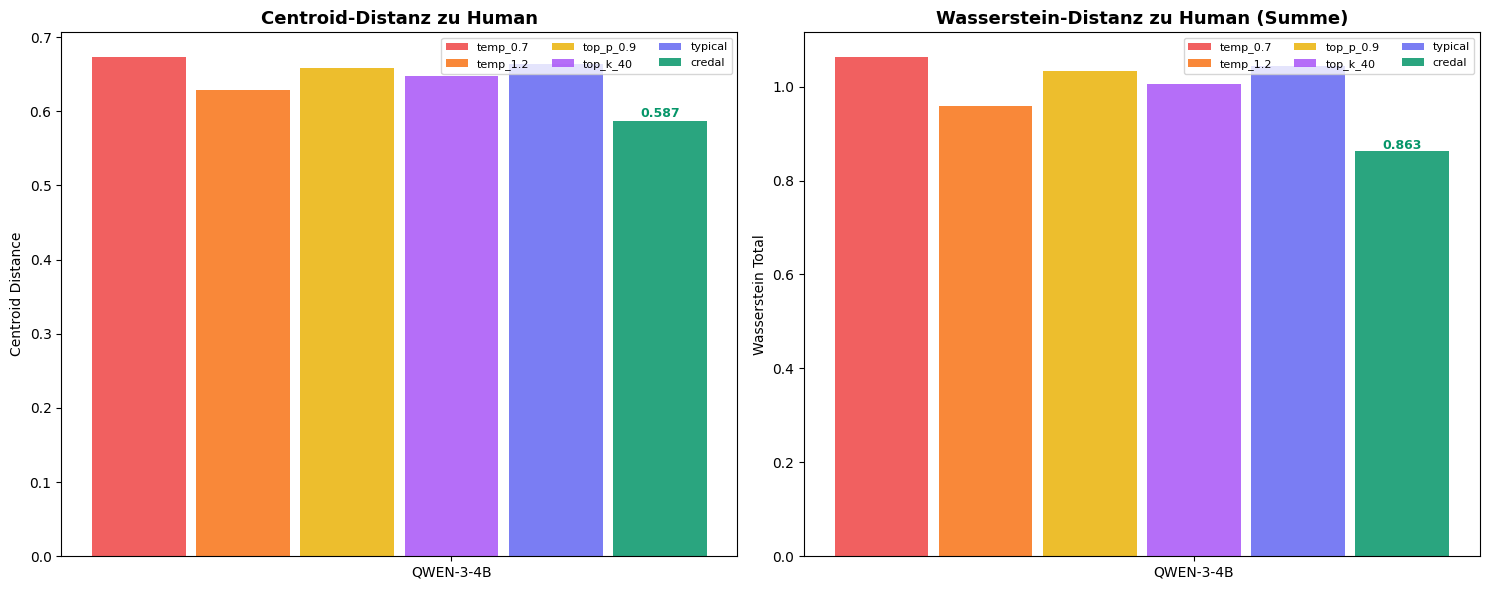

In [19]:
# Hauptmetriken-Barplot (Centroid Distance + Wasserstein Total)
n_models = len(ALL_RESULTS)
all_strats = list(STRATEGIES.keys()) + ['credal']
colors = ['#ef4444', '#f97316', '#eab308', '#a855f7', '#6366f1', '#059669']
model_list = list(ALL_RESULTS.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Centroid Distance
x = np.arange(n_models)
w = 0.8 / len(all_strats)

for i, sname in enumerate(all_strats):
    vals = [ALL_RESULTS[m].get(sname, {}).get('centroid_d', 0) for m in model_list]
    bars = ax1.bar(x + i*w, vals, w*0.9, label=sname, color=colors[i % len(colors)], alpha=0.85)
    if sname == 'credal':
        for bar, val in zip(bars, vals):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold', color='#059669')

ax1.set_xticks(x + w * len(all_strats)/2)
ax1.set_xticklabels([m.upper() for m in model_list])
ax1.set_ylabel('Centroid Distance')
ax1.set_title('Centroid-Distanz zu Human', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8, ncol=3)

# Wasserstein Total
for i, sname in enumerate(all_strats):
    vals = [ALL_RESULTS[m].get(sname, {}).get('w_total', 0) for m in model_list]
    bars = ax2.bar(x + i*w, vals, w*0.9, label=sname, color=colors[i % len(colors)], alpha=0.85)
    if sname == 'credal':
        for bar, val in zip(bars, vals):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold', color='#059669')
ax2.set_xticks(x + w * len(all_strats)/2)
ax2.set_xticklabels([m.upper() for m in model_list])
ax2.set_ylabel('Wasserstein Total')
ax2.set_title('Wasserstein-Distanz zu Human (Summe)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'main_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

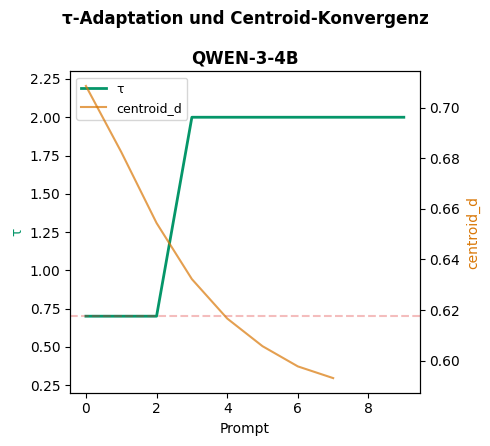

In [20]:
# Parameter-Evolution pro Modell
n = len(ALL_RESULTS)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5))
if n == 1: axes = [axes]

for ax, mname in zip(axes, ALL_RESULTS):
    hist = ALL_RESULTS[mname]['credal']['history']
    steps = [h['step'] for h in hist]
    taus = [h['tau'] for h in hist]
    cds = [h['centroid_d'] for h in hist]

    ax2 = ax.twinx()
    l1, = ax.plot(steps, taus, '-', color='#059669', lw=2, label='τ')
    ax.axhline(0.7, color='#dc2626', ls='--', alpha=0.3)
    ax.set_ylabel('τ', color='#059669')
    ax.set_ylim(0.2, max(taus) * 1.15)

    win = max(3, len(cds) // 15)
    sm = np.convolve(cds, np.ones(win)/win, 'valid')
    l2, = ax2.plot(range(len(sm)), sm, '-', color='#d97706', lw=1.5, alpha=0.7, label='centroid_d')
    ax2.set_ylabel('centroid_d', color='#d97706')

    ax.set_xlabel('Prompt')
    ax.set_title(mname.upper(), fontweight='bold')
    ax.legend(handles=[l1, l2], fontsize=9)

plt.suptitle('τ-Adaptation und Centroid-Konvergenz', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'parameter_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

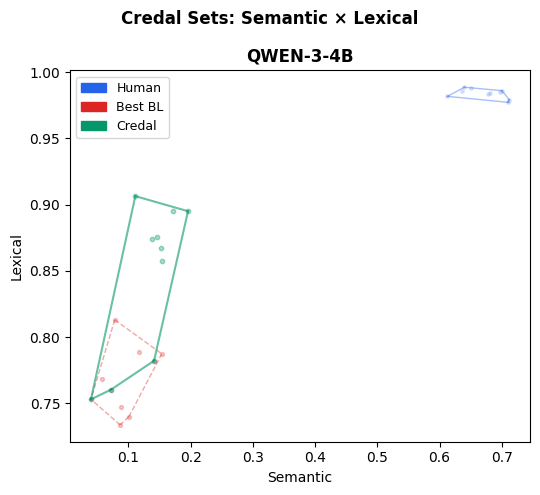

In [21]:
# Credal Sets in 2D (Semantic × Lexical)
from scipy.spatial import ConvexHull

n = len(ALL_RESULTS)
fig, axes = plt.subplots(1, n, figsize=(5.5*n, 5))
if n == 1: axes = [axes]

for ax, mname in zip(axes, ALL_RESULTS):
    # Human
    ax.scatter(human_vectors[:,0], human_vectors[:,1], c='#2563eb', alpha=0.15, s=6, zorder=1)
    try:
        hull = ConvexHull(human_vectors[:, :2])
        for s in hull.simplices:
            ax.plot(human_vectors[s, 0], human_vectors[s, 1], c='#2563eb', alpha=0.4, lw=1)
    except: pass

    # Beste Baseline
    bl_scores = {s: ALL_RESULTS[mname][s]['overlap'] for s in STRATEGIES if s in ALL_RESULTS[mname]}
    best_s = max(bl_scores, key=bl_scores.get)
    bv = ALL_RESULTS[mname][best_s]['vectors']
    ax.scatter(bv[:,0], bv[:,1], c='#dc2626', alpha=0.25, s=8, zorder=2)
    try:
        hull = ConvexHull(bv[:, :2])
        for s in hull.simplices:
            ax.plot(bv[s, 0], bv[s, 1], c='#dc2626', alpha=0.4, lw=1, ls='--')
    except: pass

    # Credal
    cv = ALL_RESULTS[mname]['credal']['vectors']
    ax.scatter(cv[:,0], cv[:,1], c='#059669', alpha=0.35, s=10, zorder=3)
    try:
        hull = ConvexHull(cv[:, :2])
        for s in hull.simplices:
            ax.plot(cv[s, 0], cv[s, 1], c='#059669', alpha=0.6, lw=1.5)
    except: pass

    ax.set_xlabel('Semantic'); ax.set_ylabel('Lexical')
    ax.set_title(mname.upper(), fontweight='bold')

from matplotlib.patches import Patch
axes[-1].legend(handles=[
    Patch(color='#2563eb', label='Human'),
    Patch(color='#dc2626', label=f'Best BL'),
    Patch(color='#059669', label='Credal'),
], fontsize=9)

plt.suptitle('Credal Sets: Semantic × Lexical', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'credal_sets_2d.png', dpi=150, bbox_inches='tight')
plt.show()

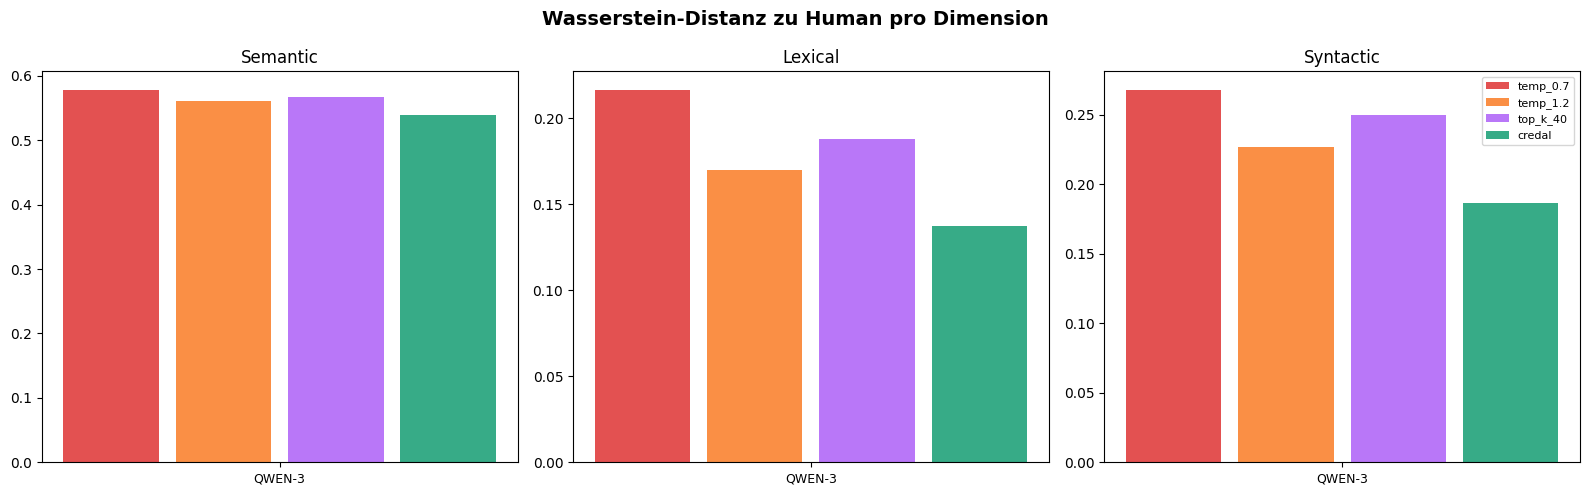

In [22]:
# Wasserstein pro Dimension
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Wasserstein-Distanz zu Human pro Dimension', fontsize=14, fontweight='bold')

compare_strats = ['temp_0.7', 'temp_1.2', 'top_k_40', 'credal']
cmap = ['#dc2626', '#f97316', '#a855f7', '#059669']
model_list = list(ALL_RESULTS.keys())

for ax, dim_i in zip(axes, range(3)):
    x = np.arange(len(model_list))
    w = 0.18
    for j, sname in enumerate(compare_strats):
        vals = [ALL_RESULTS[m].get(sname, {}).get('wasserstein', [0,0,0])[dim_i] for m in model_list]
        ax.bar(x + j*w, vals, w*0.85, label=sname, color=cmap[j], alpha=0.8)
    ax.set_title(DIM_NAMES[dim_i])
    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels([m.upper()[:6] for m in model_list], fontsize=9)
    if dim_i == 2: ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'wasserstein_per_dim.png', dpi=150, bbox_inches='tight')
plt.show()